First we going to demonstrate the difference between yule walker and burgs for finding parameters in pure AR model. 

In [1]:
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa import arima_process
import matplotlib.pyplot as plt

In [2]:
#Yule Walker equation
def yw(d,o):    #o=order of ar model
    avg=np.mean(d)
    n=len(d)
    d=d-avg       #mean centered
    #finding autocovariance function
    acvf=np.zeros(o+1)
    active_pair=np.zeros(o+1,dtype=int)
    padded_pair=np.zeros(o+1,dtype=int)
    for i in range(0,o+1):
        if i==0:
            val=np.sum(d*d)/n
        else:
            val=np.sum(d[:-i]*d[i:])/n
        acvf[i]=val
        active_pair[i]=n-i
        padded_pair[i]=i
    #finding errors, and coefficients
    alpha=np.zeros((o+1,o+1))    #coefficients 
    error=np.zeros(o+1)
    #initialization
    error[0]=acvf[0]
    alpha[1,1]=acvf[1]/error[0]
    error[1]=error[0]*(1-alpha[1,1]**2) 
    for k in range(2,o+1):
        f=k-1
        val=np.sum(alpha[f,1:k]*acvf[1:k][::-1])
        alpha[k,k]=(acvf[k]-val)/error[f]
        error[k]=error[f]*(1-alpha[k,k]**2) 
        #coefficients updates
        for c in range(1,k):
            alpha[k,c]=alpha[f,c]-alpha[k,k]*alpha[f,k-c]
    return alpha[-1,1:],active_pair,padded_pair

In [3]:
#Burg's Algorithm
def burg(d,o):
    n=len(d)
    active_length=np.zeros(o+1,dtype=int)
    alpha=np.zeros((o+1,o+1))
    u=np.zeros((o+1,n+1))
    v=np.zeros((o+1,n+1))
    #initilization
    u[0,1:]=d[::-1]
    v[0,1:]=d[::-1]
    active_length[0]=n
    for i in range(1,o+1):
        active_length[i]=n-i
        # coefficients calculation
        numerator=2.0*np.sum(v[i-1,i+1:]*u[i-1,i:-1])
        denominator=np.sum((u[i-1,i:-1])**2+(v[i-1,i+1:])**2)
        alpha[i,i]=numerator/denominator
        #error for next loop
        u[i,i+1:]= u[i-1,i:-1]-alpha[i,i]*v[i-1,i+1:]  #t=i+1
        v[i,i+1:]=v[i-1,i+1:]-alpha[i,i]*u[i-1,i:-1]
        #update coefficients
        if i==1:
           continue
        else:
            for c in range(1,i):
                alpha[i,c]=alpha[i-1,c]-alpha[i,i]*alpha[i-1,i-c]
        # print(u)
        # print(v)
    return alpha[-1,1:],active_length

In [4]:
#Generating data for AR(1) Yt=0.90X(t-1)+error
np.random.seed(67890)
params=np.array([0.90]) # coefficients of Ar model
ar_par=np.r_[1,-params]       #arima_process takes coefficient in form of Yt-0.75X(t-1)+0.26X(t-2)=error
sy=arima_process.arma_generate_sample(ar_par,ma=[1],nsample=20)    #short tsa
y_coeff,*_=yw(sy,1)
b_coeff,*_=burg(sy,1)
print(f"The coefficient by yule-walker is {y_coeff}")
print(f"The coefficient by Burgs is {b_coeff}")

The coefficient by yule-walker is [0.50634018]
The coefficient by Burgs is [0.67435396]


This shows Burg's algorithm is superior estimator for short time frame data. Yule walker underestimates the parameter by nearly 45% while burgs underestimated the parameter by only 25%.Yule walker performs poor because of global 1/N scaling windowing constraints and boundary shrinkage fraction(i/N) is high.

In [5]:
#Generating data for AR(2) Yt=0.75X(t-1)-0.26X(t-2)+error
np.random.seed(678900)
params=np.array([0.75,-0.26]) # coefficients of Ar model
ar_par=np.r_[1,-params] #arima_process takes coefficient in form of Yt-0.75X(t-1)+0.26X(t-2)=error
sy=arima_process.arma_generate_sample(ar_par,ma=[1],nsample=500)
for i in [30,100,200,500]:
    y_coeff,*_=yw(sy[:i],2)
    b_coeff,*_=burg(sy[:i],2)
    print(f"The coefficient for n={i} by yule-walker and burgs are {y_coeff} and {b_coeff} respectively.")


The coefficient for n=30 by yule-walker and burgs are [ 0.71917318 -0.15683557] and [ 0.77016957 -0.13454516] respectively.
The coefficient for n=100 by yule-walker and burgs are [ 0.77949591 -0.15493297] and [ 0.79967098 -0.1699041 ] respectively.
The coefficient for n=200 by yule-walker and burgs are [ 0.6776252  -0.16901446] and [ 0.69762215 -0.18329094] respectively.
The coefficient for n=500 by yule-walker and burgs are [ 0.77049287 -0.29754398] and [ 0.77258637 -0.29880539] respectively.


As the sample size increases, the coefficents obtained by both method are nearly same. Because as the sample size increase the boundary shrinkage fraction(i/N) decreases. When boundary edge is minimized , the global Toeplitz matrix yields same vector projection as Burg's lattice minimixation.

In [6]:
#Frequency Response of AR Coefficients
def psd(ecoeff,tcoeff,order,label,color):
    tpsd=[]
    wgrid = np.linspace(0, np.pi, 500)
    freqs = wgrid / (2 * np.pi)
    for w in wgrid:
        summ = sum(tcoeff[o] * np.exp(-1j * (o + 1) * w) for o in range(order))
        tpsd.append(1.0 / (np.abs(1.0 - summ) ** 2))
    true_frequency = freqs[np.argmax(tpsd)]
    epsd=[]
    for w in wgrid:
        summ = sum(ecoeff[o] * np.exp(-1j * (o + 1) * w) for o in range(order))
        epsd.append(1.0 / (np.abs(1.0 - summ) ** 2))
    epsdarr=np.array(epsd)
    plt.figure(figsize=(10, 5))
    plt.plot(freqs, 10 * np.log10(epsdarr), label=label, color=color)
    plt.axvline(true_frequency,color="black",linestyle="--",label=f"True Frequency ({true_frequency:.4f})",)
    plt.title("The Major Difference: Resolution vs. Stability")
    plt.xlabel("Normalized Frequency")
    plt.ylabel("Power Spectral Density (dB)")
    plt.legend()
    plt.grid(True)
    plt.show()          

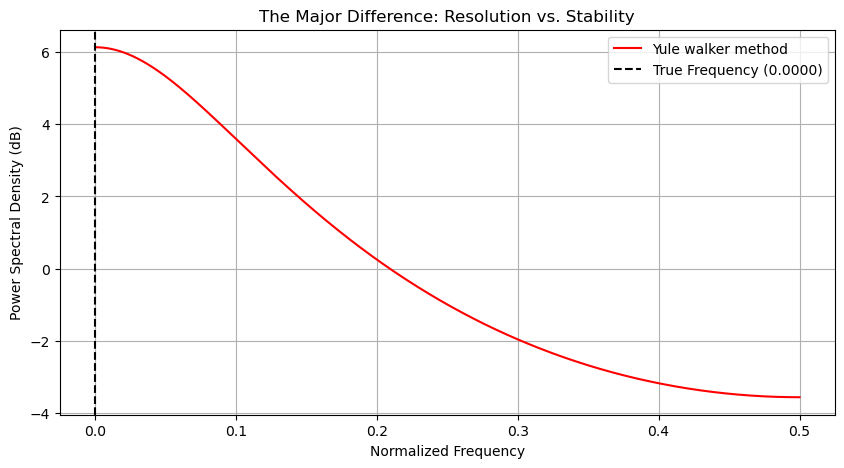

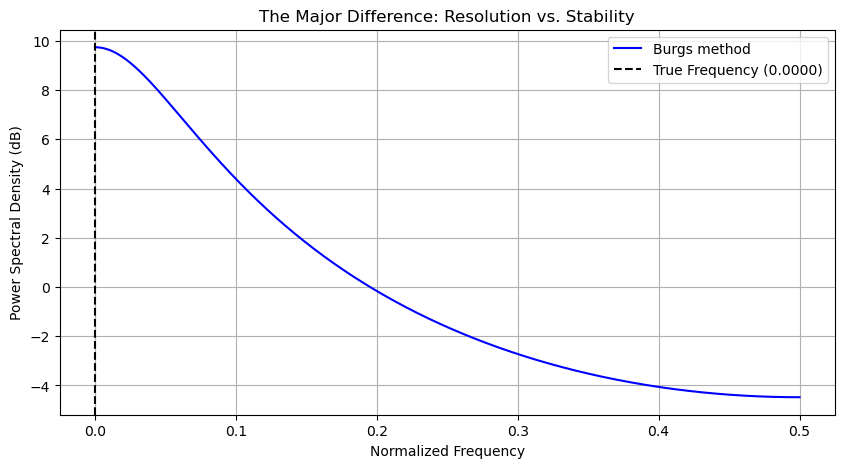

In [12]:
#for AR(1)
psd([0.50634018],[0.90],1,"Yule walker method","red")
psd([0.67435396],[0.90],1,"Burgs method","blue")

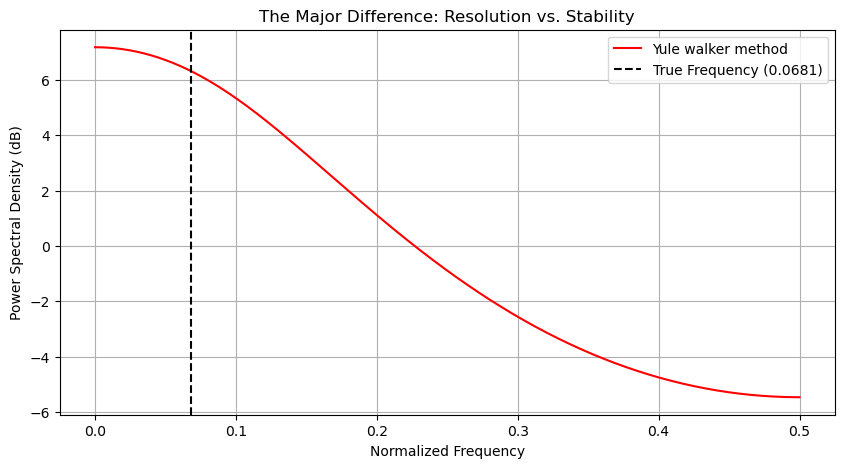

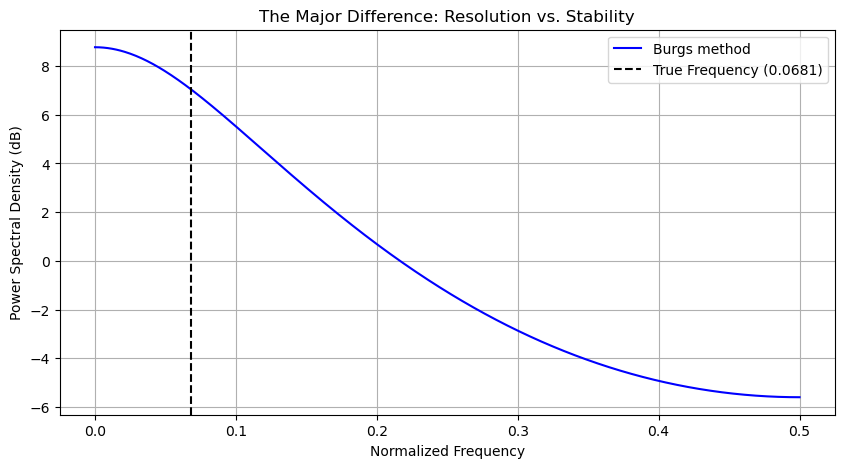

In [8]:
#for AR2,i=30
psd([ 0.71917318,-0.15683557],[0.75,-0.26],2,"Yule walker method","red")
psd([ 0.77016957,-0.13454516],[0.75,-0.26],2,"Burgs method","blue")

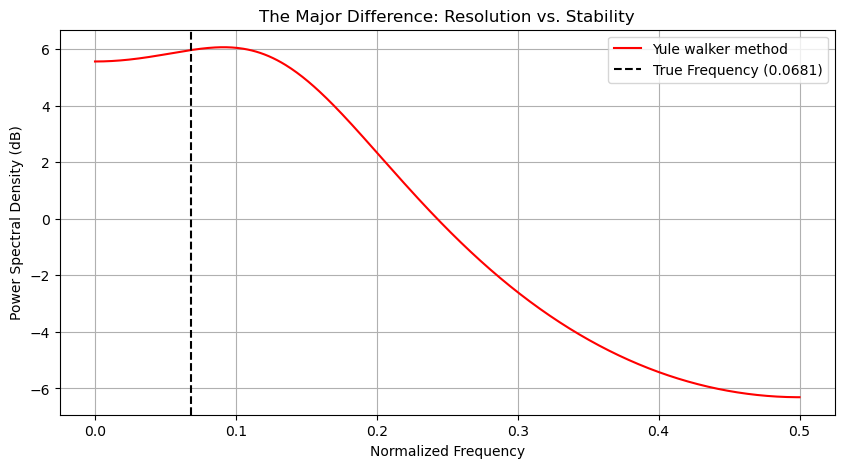

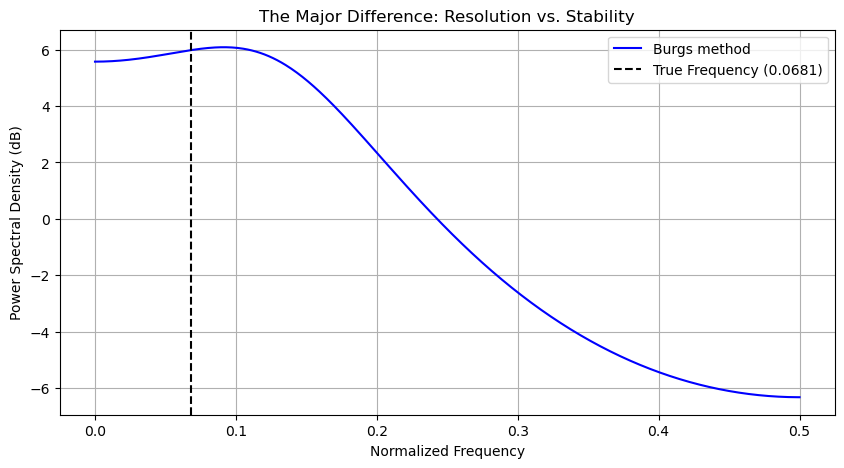

In [11]:
#for i=500
psd([ 0.77049287,-0.29754398],[0.75,-0.26],2,"Yule walker method","red")
psd([ 0.77258637,-0.29880539],[0.75,-0.26],2,"Burgs method","blue")

Conclusion
For small samples, both yule walker and burgs fails to attain true coefficients because of estimation bias. But Burgs algortith prediction is slightly better than yule wlakers and burgs holds higher signal energy due to its lattice based minimization of forward and backward errors.
Incase of large samples, both algorithms successfully estimate coefficients very close to true coefficients, resulting in virtually identical power spectral density curve.